In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from langdetect import detect, DetectorFactory

In [4]:
df = pd.read_csv("spotify_dataset.csv")
df = df.drop_duplicates(subset=['track_name','artists'], keep='first').reset_index(drop=True)

feature_cols = ['acousticness', 'instrumentalness', 'speechiness','energy',
                 'loudness','tempo', 'danceability', 'valence', 
                 'liveness', 'key', 'mode', 'time_signature']

data = df[feature_cols].copy() # dataset copy with just numerical values

In [5]:
DetectorFactory.seed = 0
def get_language(text):
    try:
        return(detect(str(text)))
    except:
        return "Unknown"
    
print("Scanning track names for language")
df['language'] = df["track_name"].apply(get_language)

print(df['language'].value_counts().head())

Scanning track names for language
language
en    31360
de     6484
pt     6471
es     4601
id     2633
Name: count, dtype: int64


In [6]:
# Song/Artist Index Search
def find_song(query):
    return df[df['track_name'].str.contains(query, case=False) | 
              df['artists'].str.contains(query, case=False)][['track_name', 'artists']]

find_song("Zeppelin")

,track_name,artists
37881,Immigrant Song - Remaster,Led Zeppelin
37884,Stairway to Heaven - Remaster,Led Zeppelin
37903,Whole Lotta Love - 1990 Remaster,Led Zeppelin
37935,Black Dog - Remaster,Led Zeppelin
37937,Kashmir - Remaster,Led Zeppelin
38020,Rock and Roll - Remaster,Led Zeppelin
38023,Good Times Bad Times - 1993 Remaster,Led Zeppelin
38058,When the Levee Breaks - Remaster,Led Zeppelin
38064,Ramble On - 1990 Remaster,Led Zeppelin
38092,Tangerine - Remaster,Led Zeppelin


In [7]:
# Macro Genres for combining genres
macro = {
    # Classic and Hard Rock
    'rock': "Classic_Rock",
    'british': "Classic_Rock",
    'rock-n-roll': "Classic_Rock",
    'hard-rock': "Classic_Rock",
    'psych-rock': "Classic_Rock",
    'guitar': "Classic_Rock",
    
    # Alt 
    'punk': "Alt_indie",
    'alt-rock': "Alt_indie",
    'indie': "Alt_indie",
    'punk_rock': "Alt_indie",
    'grunge': "Alt_indie",
    'alternative': "Alt_indie",
    
    # Pop and synth
    'synth-pop': "Pop_synth",
    'pop': "Pop_synth",
    'power-pop': "Pop_synth",
    'piano': "Pop_synth",
    'power-pop': "Pop_synth",
    'indie-pop': "Pop_synth",
    'acoustic': "Pop_synth",
    'singer-songwriter': "Pop_synth",


    # World
    'indian': "World",
    'swedish': "World",
    'afrobeat': "World",
    'french': "World",
    'samba': "World",
    'turkish': "World",
    'latin': "World",
    'pagode': "World",
    'tango': "World",
    'world-music': "World",
    'latino': "World",
    'spanish': "World",
    'brazil': "World",
    'german': "World",
    'iranian': "World",
    'malay': "World",
    'reggaeton': "World",
    'k-pop': "World",
    'j-pop': "World",
    'j-rock': "World",
    'mandopop': "World",
    'cantopop': "World",

    # Electronic
    'edm': 'Electronic', 
    'house': 'Electronic', 
    'techno': 'Electronic',
    'trance': 'Electronic', 
    'dubstep': 'Electronic', 
    'dance': 'Electronic',
    'deep-house': 'Electronic', 
    'electronic': 'Electronic', 
    'club': 'Electronic',
    'breakbeat': 'Electronic', 
    'drum-and-bass': 'Electronic', 
    'idm': 'Electronic',

    # Metal
    'metal': 'Metal',
    'heavy-metal': 'Metal', 
    'black-metal': 'Metal',
    'death-metal': 'Metal', 
    'metalcore': 'Metal', 
    'grindcore': 'Metal',

    # Jazz, blues, soul, r&b
    'jazz': 'JBSRNB', 'blues': "JBSRNB", 'soul': "JBSRNB",
    'r-n-b': "JBSRNB", 'funk': "JBSRNB", 'disco': "JBSRNB",

    # Country and folk
    'country': 'Country_Folk', 'folk': 'Country_Folk', 'bluegrass': 'Country_Folk',
    'honky-tonk': 'Country_Folk'
}
# anything not in this list becomes "other" - edit later for greater accuracy
df['macro'] = df['track_genre'].map(lambda x: macro.get(x, "Other"))

print("Macro Genre Distribution")
print(df['macro'].value_counts())




Macro Genre Distribution
macro
Other           36123
World           16161
Electronic       7957
Metal            4707
Pop_synth        4366
Classic_Rock     3817
Country_Folk     3119
JBSRNB           2999
Alt_indie        2095
Name: count, dtype: int64


In [8]:
# Feature Engineering - scaling, one-hot encoding, and weighting
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

macro_dummies = pd.get_dummies(df['macro'], prefix='macro')

macro_weighted = macro_dummies * 2.5


In [9]:
# Tensor creation
combined_data = np.hstack([scaled_data, macro_weighted])
X = torch.tensor(combined_data).float()

In [10]:
# Data loader 
dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=64, shuffle= True) # batch size use powers of 2
print(f"Data shape check: {X.shape}")

Data shape check: torch.Size([81344, 21])


Autoencoder Setup

In [11]:
class SongAutoencoder(nn.Module):
    def __init__(self, input_dimension):
        super(SongAutoencoder, self).__init__()

        # Encoder - going to squeeze 12 to 64 to 12
        # expand to 64 to find correlations then map back to 12
        self.encoder = nn.Sequential(
            nn.Linear(input_dimension, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU()
        )

        # Decoder - reconstructing 12 features from 4
        self.decoder = nn.Sequential(
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, input_dimension)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [12]:
model = SongAutoencoder(X.shape[1])
print(model)

SongAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=12, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=21, bias=True)
  )
)


Training Loop

Epoch [30/30] complete. Error: 0.0063


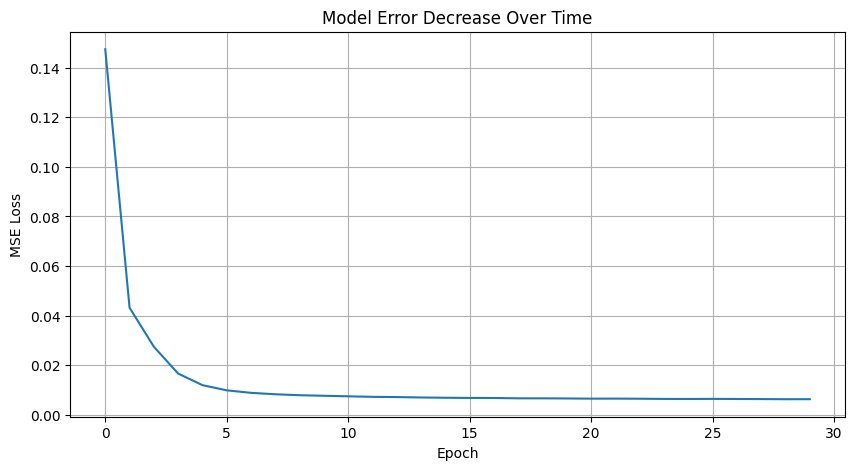

In [13]:
error_formula = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001) # why this learning rate

epochs = 30
losses = []

for epoch in range(epochs):
    error_this_epoch = 0

    for batch in dataloader:
        # get one batch of songs (64 each time)
        inputs = batch[0]

        # clear gradients (memory) from previous step
        optimizer.zero_grad()

        # forward pass: model tries reconstructing song "dna"
        outputs = model(inputs)
        
        # calculate error for this specific batch
        loss = error_formula(outputs, inputs)

        # backpropagation - calculate how much to change each weight
        loss.backward()

        # update and adjust weights
        optimizer.step()

        # accumulate error to list
        error_this_epoch += loss.item()

    avg_loss = error_this_epoch / len(dataloader)
    losses.append(avg_loss)

if (epoch + 1) % 5 == 0:
    print(f"Epoch [{epoch + 1}/{epochs}] complete. Error: {avg_loss:.4f}")

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Model Error Decrease Over Time")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


In [14]:
# Switch model out of training mode and into evaluation
model.eval()

# Generate latent representations (embeddings) - no gradient to save memory
with torch.no_grad():
    # pass entire X tensor through just encoder part
    latent_embeddings = model.encoder(X)

# Convert to Numpy array
embedding_matrix = latent_embeddings.numpy()

print(f"Embedding Matrix Shape: {embedding_matrix.shape}")
print(f"Latent vector for first song: \n{embedding_matrix[0]}")


Embedding Matrix Shape: (81344, 12)
Latent vector for first song: 
[ 7.044432   2.1440854 10.422046   2.2441182  1.515105   4.678205
  2.9120843  2.85673    6.305155   5.8205714  7.091862   2.736958 ]


In [19]:
# Recommender Function
from sklearn.metrics.pairwise import cosine_similarity

def get_recommendations(song_index, n_recs=5):
    # Get 4D Latent vector from base song
    # reshape into a 2d array
    query_vector = embedding_matrix[song_index].reshape(1, -1)

    # Calculate similarity score against all songs in df. 1.0 = identical, 0.0 = opposite
    similarity_scores = cosine_similarity(query_vector, embedding_matrix)[0]

    base_lang = df.iloc[song_index]['language']
    # mask
    lang_mask = (df['language'] == base_lang).astype(float)
    lang_mask[lang_mask == 0] = 0.0001

    final_scores = similarity_scores * lang_mask

    # Find indices of highest scores - use n+1 because base song will be perfect match
    top_indices = final_scores.argsort()[-(n_recs + 1):-1][::-1]

    # Display results using original uncopied dataframe:
    base_song = df.iloc[song_index]
    print(f"If you like: '{base_song["track_name"]}' by {base_song['artists']}")
    print("="*50)

    for rank, index in enumerate(top_indices, 1):
        match = df.iloc[index]
        score = final_scores[index]
        print(f"{rank}. {match['track_name']} | {match['artists']} ({score:.2%} Match)")
    
    return top_indices

top_indices = get_recommendations(38064)




If you like: 'Ramble On - 1990 Remaster' by Led Zeppelin
1. Break on Through (To the Other Side) | The Doors (99.91% Match)
2. He Can Only Hold Her | Amy Winehouse (99.89% Match)
3. You Know I'm No Good | Amy Winehouse (99.87% Match)
4. Muñequita (Roly Poly) | Enrique Guzman (99.87% Match)
5. Taxman - Remastered 2009 | The Beatles (99.86% Match)


In [16]:
# Check the genres of the results
df.iloc[[38064] + list(top_indices)][['track_name', 'artists', 'track_genre']]

,track_name,artists,track_genre
38064,Ramble On - 1990 Remaster,Led Zeppelin,hard-rock
63090,Break on Through (To the Other Side),The Doors,psych-rock
9865,He Can Only Hold Her,Amy Winehouse,british
9496,You Know I'm No Good,Amy Winehouse,british
65212,Muñequita (Roly Poly),Enrique Guzman,rock-n-roll
9868,Taxman - Remastered 2009,The Beatles,british


In [17]:


# 1. Grab the indices from your last run
comparison_indices = [38064] + list(top_indices)

# 2. Create the vertical table
vibe_dashboard = df.iloc[comparison_indices].copy()
vibe_dashboard.set_index('track_name', inplace=True)

# 3. Transpose and highlight the "Leader" (the first column)
# We round to 3 decimals to keep it readable
vibe_dashboard = vibe_dashboard[feature_cols].T

print("Vibe Comparison Dashboard:")
display(vibe_dashboard.style.background_gradient(axis=1, cmap='viridis').format(precision=3))

Vibe Comparison Dashboard:


track_name,Ramble On - 1990 Remaster,Break on Through (To the Other Side),He Can Only Hold Her,You Know I'm No Good,Muñequita (Roly Poly),Taxman - Remastered 2009
acousticness,0.072,0.200,0.021,0.014,0.335,0.010
instrumentalness,0.001,0.000,0.008,0.004,0.000,0.000
speechiness,0.034,0.047,0.073,0.033,0.032,0.075
energy,0.607,0.751,0.504,0.496,0.534,0.596
loudness,-11.367,-9.584,-14.978,-14.222,-9.032,-8.348
tempo,98.429,89.839,98.391,103.372,103.359,133.586
danceability,0.468,0.421,0.626,0.694,0.550,0.469
valence,0.886,0.789,0.713,0.799,0.944,0.783
liveness,0.225,0.170,0.068,0.064,0.236,0.321
key,9.000,9.000,11.000,9.000,8.000,7.000


Song Search Function within dataframe with duplicates removed

Genre Lookup

In [18]:
def show_unique_genres(dataframe):
    unique_genres = sorted(dataframe['track_genre'].unique())

    print(f"Total Unique Labels: {len(unique_genres)}")
    
    # print in grid w/ 5 columns
    for i in range(0, len(unique_genres), 5):
        print(" | ".join(f"{g:<20}" for g in unique_genres[i:i+5]))

show_unique_genres(df)

Total Unique Labels: 113
acoustic             | afrobeat             | alt-rock             | alternative          | ambient             
anime                | black-metal          | bluegrass            | blues                | brazil              
breakbeat            | british              | cantopop             | chicago-house        | children            
chill                | classical            | club                 | comedy               | country             
dance                | dancehall            | death-metal          | deep-house           | detroit-techno      
disco                | disney               | drum-and-bass        | dub                  | dubstep             
edm                  | electro              | electronic           | emo                  | folk                
forro                | french               | funk                 | garage               | german              
gospel               | goth                 | grindcore            | gr

In [20]:
# Check the language tags for Zeppelin and the results
print("Language Tag Audit:")
print("-" * 30)
# This looks at Zeppelin (38064) and your current top_indices
print(df.loc[[38064] + list(top_indices)][['track_name', 'artists', 'language']])

Language Tag Audit:
------------------------------
                                 track_name         artists language
38064             Ramble On - 1990 Remaster    Led Zeppelin       en
63090  Break on Through (To the Other Side)       The Doors       en
9865                   He Can Only Hold Her   Amy Winehouse       en
9496                   You Know I'm No Good   Amy Winehouse       en
65212                 Muñequita (Roly Poly)  Enrique Guzman       en
9868               Taxman - Remastered 2009     The Beatles       en
